#Fairness Analysis: Auto Insurance Prediction Model
### Are Blue-Collar Customers Treated Fairly?

## Background

Our company uses a logistic regression model to predict the probability that an auto-insurance customer will file at least one claim in the next year. Management plans to **cancel policies** for customers whose predicted probability exceeds **60%**, which is expected to affect roughly the highest-risk 10% of the book.

A recurring concern from insurance agents is that the model may be systematically unfair to customers in **blue-collar jobs** (trades workers such as electricians, plumbers, and construction workers). This notebook investigates that claim by analyzing the model's predictions through the lens of standard algorithmic fairness metrics.

The two groups we compare throughout are:
- **Blue Collar** (`job_bluecollar = 1`): 2,158 customers
- **Non-Blue Collar** (`job_bluecollar = 0`): 7,498 customers

> **Important note on the outcome variable:** We treat `hadclaim = 1` as ground truth. In a real-world fairness review one would also question whether the claim records themselves are recorded consistently across job classes. We assume they are here.


## 1. Setup and Data Loading

In [1]:
# Core data and numeric libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Model evaluation
from sklearn.calibration import calibration_curve
from sklearn.metrics import roc_curve, auc
import statsmodels.api as sm

# Plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110


In [2]:
# Load the data

url = "https://raw.githubusercontent.com/justinsydnor/GB894/refs/heads/main/autodata.csv"

df = pd.read_csv(url)

# Create the binary high-risk flag at the company's chosen 60% threshold
df["highrisk"] = (df["probclaim"] > 0.60).astype(int)

print(f"Total customers: {len(df):,}")
print(f"Blue-collar customers: {df['job_bluecollar'].sum():,}")
print(f"Non-blue-collar customers: {(1 - df['job_bluecollar']).sum():,}")


Total customers: 9,656
Blue-collar customers: 2,158
Non-blue-collar customers: 7,498


## 2. Base Rates and Predicted Probabilities

We begin by asking two questions: (1) Do blue-collar customers actually file claims at higher rates than other customers? And (2) does the model assign them higher predicted probabilities on average?

### 2a. Actual claim rates by group


In [3]:
# Actual claim rates by group
claim_rates = df.groupby("job_bluecollar")["hadclaim"].mean().rename({0: "Non-Blue Collar", 1: "Blue Collar"})
claim_rates.index.name = "Job Class"
print("Actual Claim Rate by Job Class")
print(claim_rates.round(4).to_string())


Actual Claim Rate by Job Class
Job Class
Non-Blue Collar    0.2413
Blue Collar        0.3499


We see here that blue-collar customers have a meaningfully higher actual claim rate (**35.0%**) than non-blue-collar customers (**24.1%**). This is the underlying statistical reality the model is working with, and it is important context for the fairness analysis that follows.

### 2b. Distribution of predicted probabilities


In [4]:
# Summary statistics of predicted probabilities by group
prob_stats = df.groupby("job_bluecollar")["probclaim"].agg(["min", "mean", "max"])
prob_stats.index = ["Non-Blue Collar", "Non-Blue Collar", "Blue Collar", "Blue Collar"][::2][:2]

# cleaner approach
prob_stats = df.groupby("job_bluecollar")["probclaim"].agg(["min", "mean", "max"]).round(4)
prob_stats.index = ["Non-Blue Collar", "Blue Collar"]
prob_stats.index.name = "Job Class"
print("Predicted Probability Summary by Job Class")
print(prob_stats.to_string())


Predicted Probability Summary by Job Class
                    min    mean     max
Job Class                              
Non-Blue Collar  0.0019  0.2457  0.9540
Blue Collar      0.0045  0.3346  0.9519


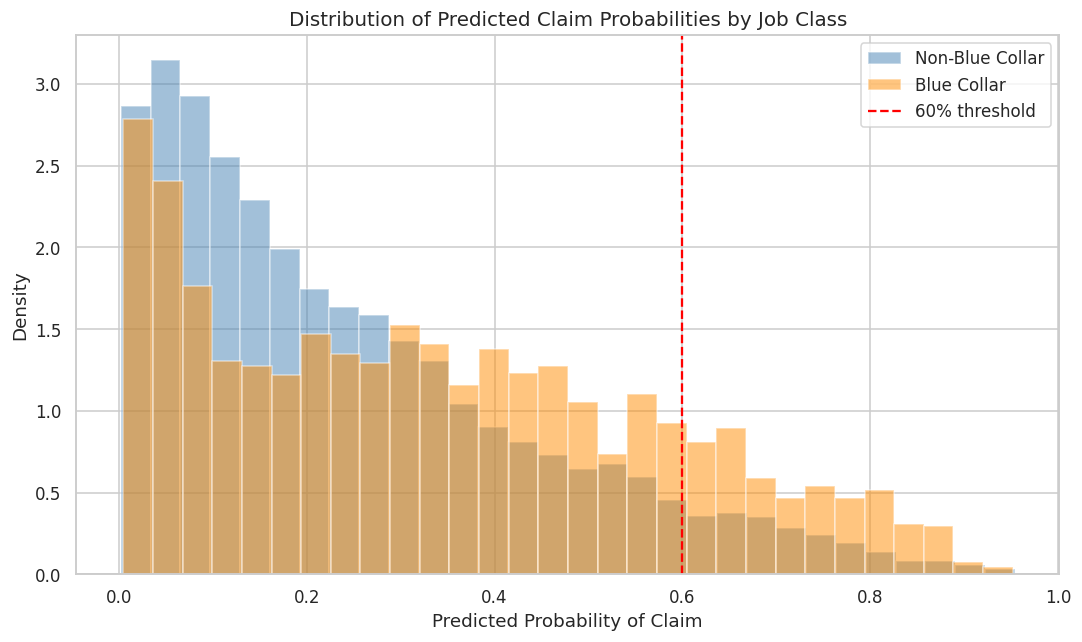

In [5]:
# Overlapping histograms of predicted probabilities
fig, ax = plt.subplots(figsize=(10, 6))

for label, group, color in [("Non-Blue Collar", 0, "steelblue"), ("Blue Collar", 1, "darkorange")]:
    sub = df[df["job_bluecollar"] == group]
    ax.hist(sub["probclaim"], bins=30, density=True, alpha=0.5, color=color, label=label, edgecolor="white")

ax.axvline(0.60, color="red", linestyle="--", linewidth=1.5, label="60% threshold")
ax.set_xlabel("Predicted Probability of Claim", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Distribution of Predicted Claim Probabilities by Job Class", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


The distribution of predicted probabilities is shifted to the right for blue-collar customers (mean = 33.5%) relative to non-blue-collar customers (mean = 24.6%). Importantly, the red dashed line at the 60% cancellation threshold falls deeper into the blue-collar distribution, meaning a larger share of blue-collar customers will be flagged as high-risk.

### 2c. Kernel Density Comparison


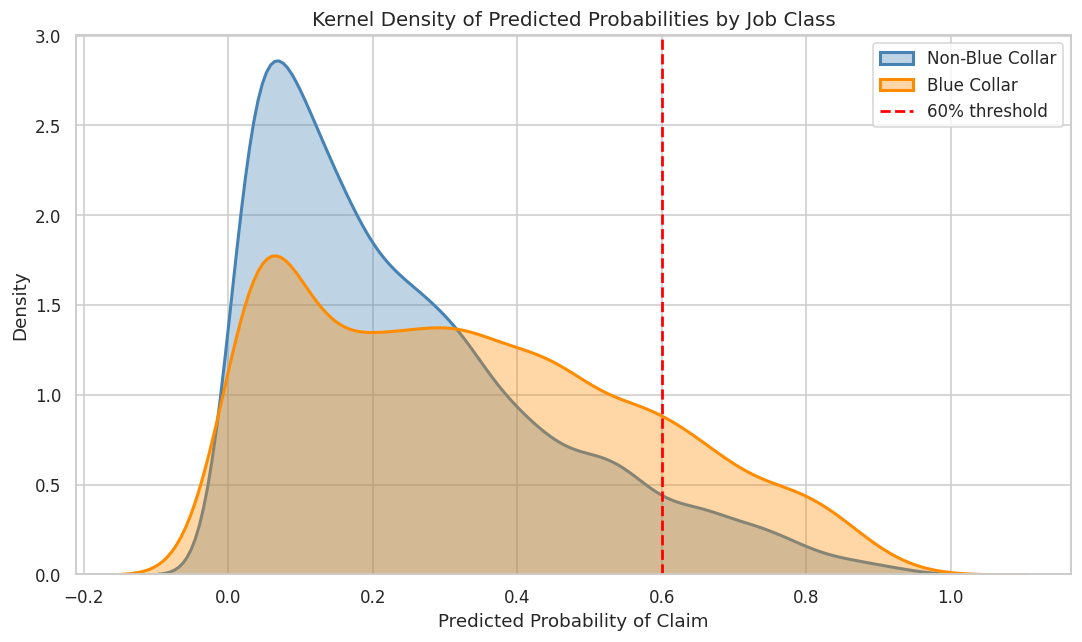

In [6]:
# KDE plot for a clearer look at the distributional shift
fig, ax = plt.subplots(figsize=(10, 6))
for label, group, color in [("Non-Blue Collar", 0, "steelblue"), ("Blue Collar", 1, "darkorange")]:
    sub = df[df["job_bluecollar"] == group]
    sns.kdeplot(sub["probclaim"], ax=ax, fill=True, alpha=0.35, color=color, label=label, linewidth=2)

ax.axvline(0.60, color="red", linestyle="--", linewidth=1.8, label="60% threshold")
ax.set_xlabel("Predicted Probability of Claim", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title("Kernel Density of Predicted Probabilities by Job Class", fontsize=13)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


## 3. Classification and Cancellation Rates

Now we look at how many customers in each group are flagged as high-risk (i.e., will have their policy cancelled).


In [7]:
# Share of each group flagged as high-risk and share with actual claims
classification_table = df.groupby("job_bluecollar")[["highrisk", "hadclaim"]].mean().round(4)
classification_table.index = ["Non-Blue Collar", "Blue Collar"]
classification_table.columns = ["% Flagged High-Risk (Cancelled)", "% Actual Claimants"]
classification_table.index.name = "Job Class"
print(classification_table.to_string())
print()

# Representation among cancelled customers
bc_share_pop = df["job_bluecollar"].mean()
bc_share_cancelled = df[df["highrisk"] == 1]["job_bluecollar"].mean()
print(f"Blue-collar share of total customer base: {bc_share_pop:.1%}")
print(f"Blue-collar share of cancelled customers:  {bc_share_cancelled:.1%}")


                 % Flagged High-Risk (Cancelled)  % Actual Claimants
Job Class                                                           
Non-Blue Collar                           0.0722              0.2413
Blue Collar                               0.1599              0.3499

Blue-collar share of total customer base: 22.3%
Blue-collar share of cancelled customers:  38.9%


At the 60% threshold, we have:
- **16.0%** of blue-collar customers will have their policy cancelled.
- Only **7.2%** of non-blue-collar customers will be cancelled.

Blue-collar customers make up **22.4%** of the total customer base but account for **38.9%** of all cancellations, which is a major over-representation. The cancellation rate for blue-collar customers is more than **twice as high** as for other customers.

### 3a. Cancellation rates across all job classes

To put this in broader context, here is how cancellation rates compare across all job categories.


In [8]:
# Cancellation and claim rates across all job classes
jobclass_summary = df.groupby("jobclass").agg(
    N=("hadclaim", "count"),
    Claim_Rate=("hadclaim", "mean"),
    Cancel_Rate=("highrisk", "mean"),
    Avg_Pred_Prob=("probclaim", "mean")
).round(4).sort_values("Cancel_Rate", ascending=False)

print("Summary by Job Class (sorted by cancellation rate)")
print(jobclass_summary.to_string())


Summary by Job Class (sorted by cancellation rate)
                 N  Claim_Rate  Cancel_Rate  Avg_Pred_Prob
jobclass                                                  
Student        841      0.3746       0.2176         0.3561
Blue Collar   2158      0.3499       0.1599         0.3346
Clerical      1506      0.3041       0.0890         0.2544
Home Maker     776      0.2680       0.0657         0.2292
Professional  1312      0.2302       0.0587         0.2387
Unknown        615      0.2667       0.0423         0.2797
Manager       1184      0.1275       0.0363         0.2307
Lawyer         967      0.1830       0.0228         0.1778
Doctor         297      0.1145       0.0168         0.1726


We see that blue-collar workers have the second-highest cancellation rate (16.0%), behind only students (21.8%). Their claim rate is also second-highest, but the question we must answer is whether the *model's* treatment of blue-collar workers is appropriate relative to their actual risk. We examine this next.


## 4. Model Calibration

A model is **well-calibrated** if, among customers assigned a predicted probability of X%, approximately X% of them actually have a claim. Poor calibration means the model is systematically over- or under-predicting for a group. Importantly, if the model is well-calibrated for both groups, that provides one measure of fairness (often called "calibration fairness").

### 4a. Calibration curves


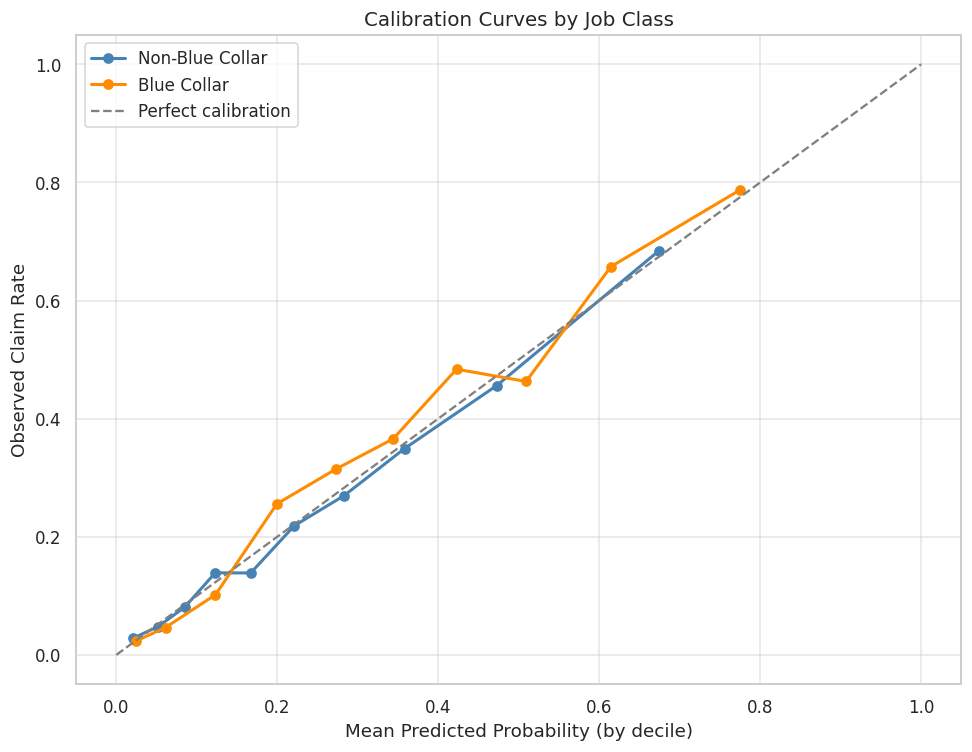

In [9]:
# Calibration curves by group
fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: "steelblue", 1: "darkorange"}
labels = {0: "Non-Blue Collar", 1: "Blue Collar"}

for g in [0, 1]:
    sub = df[df["job_bluecollar"] == g]
    prob_true, prob_pred = calibration_curve(sub["hadclaim"], sub["probclaim"], n_bins=10, strategy="quantile")
    ax.plot(prob_pred, prob_true, marker="o", color=colors[g], linewidth=2, label=labels[g])

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Perfect calibration")
ax.set_xlabel("Mean Predicted Probability (by decile)", fontsize=12)
ax.set_ylabel("Observed Claim Rate", fontsize=12)
ax.set_title("Calibration Curves by Job Class", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()


The **non-blue-collar** group lies close to the 45-degree perfect-calibration line throughout the range, so the model predicts their claim rates well. The **blue-collar** group, by contrast, shows a more irregular pattern and shows signs of **under-prediction** in the mid-range (roughly 20%–50% predicted probability), where the observed claim rate is higher than the model predicts.

This means the model is **less accurate for blue-collar customers at intermediate risk levels**, but not in a way that uniformly harms them at the 60% cancellation threshold. We explore this further with a regression test.

### 4b. Regression test for differential calibration


In [10]:
# Regression: hadclaim ~ probclaim + job_bluecollar
# A well-calibrated model would show: intercept ≈ 0, coef on probclaim ≈ 1, coef on job_bluecollar ≈ 0

X = sm.add_constant(df[["probclaim", "job_bluecollar"]])
ols_model = sm.OLS(df["hadclaim"], X).fit()
print(ols_model.summary().tables[1])


                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             -0.0039      0.006     -0.606      0.545      -0.017       0.009
probclaim          0.9980      0.019     52.724      0.000       0.961       1.035
job_bluecollar     0.0198      0.010      2.066      0.039       0.001       0.039


The regression confirms a statistically significant positive coefficient on `job_bluecollar` (coef ≈ +0.020, p = 0.039). This means that **holding predicted probability constant, blue-collar customers have actual claim rates that are about 2 percentage points higher than predicted**. In other words, the model **under-predicts risk for blue-collar customers**, which is a subtle but meaningful miscalibration.

This is an important form of potential unfairness: the model may not be capturing the true risk factors that drive blue-collar claims, and as a result, some mid-range blue-collar customers may be *under*-flagged while others near the 60% boundary may be flagged somewhat arbitrarily.


## 5. Accuracy and Discriminative Power

### 5a. Overall classification accuracy


In [11]:
# Accuracy = share of correct predictions at 60% threshold
df["correct"] = (((df["highrisk"] == 1) & (df["hadclaim"] == 1)) |
                 ((df["highrisk"] == 0) & (df["hadclaim"] == 0))).astype(int)

accuracy = df.groupby("job_bluecollar")["correct"].mean().round(4)
accuracy.index = ["Non-Blue Collar", "Blue Collar"]
accuracy.index.name = "Job Class"
print("Accuracy at 60% Threshold")
print(accuracy.to_string())


Accuracy at 60% Threshold
Job Class
Non-Blue Collar    0.7909
Blue Collar        0.7303


The model is modestly less accurate for blue-collar customers (**73.0%**) than for non-blue-collar customers (**79.1%**) at the 60% threshold. This reflects a meaningful performance gap.

### 5b. Accuracy across all thresholds


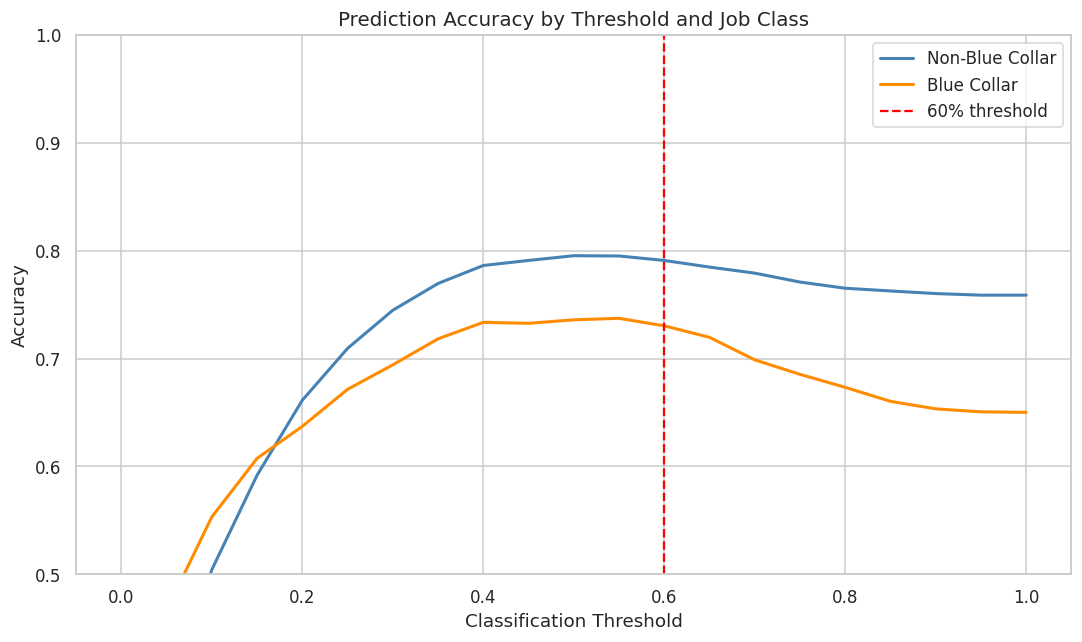

In [12]:
# Accuracy across thresholds
thresholds = [x / 100 for x in range(0, 101, 5)]
accuracy_by_group = {0: [], 1: []}

for g in [0, 1]:
    sub = df[df["job_bluecollar"] == g]
    for t in thresholds:
        pred = (sub["probclaim"] >= t).astype(int)
        acc = ((pred == sub["hadclaim"]).sum()) / len(sub)
        accuracy_by_group[g].append(acc)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, accuracy_by_group[0], color="steelblue", linewidth=2, label="Non-Blue Collar")
ax.plot(thresholds, accuracy_by_group[1], color="darkorange", linewidth=2, label="Blue Collar")
ax.axvline(0.60, color="red", linestyle="--", linewidth=1.5, label="60% threshold")
ax.set_xlabel("Classification Threshold", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Prediction Accuracy by Threshold and Job Class", fontsize=13)
ax.set_ylim(0.5, 1.0)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()


We see that at virtually every threshold, the model is more accurate for non-blue-collar customers than for blue-collar customers. The accuracy gap is most pronounced around the 60–80% threshold range, which is where the policy's cancellation decision is being made.

### 5c. ROC-AUC analysis


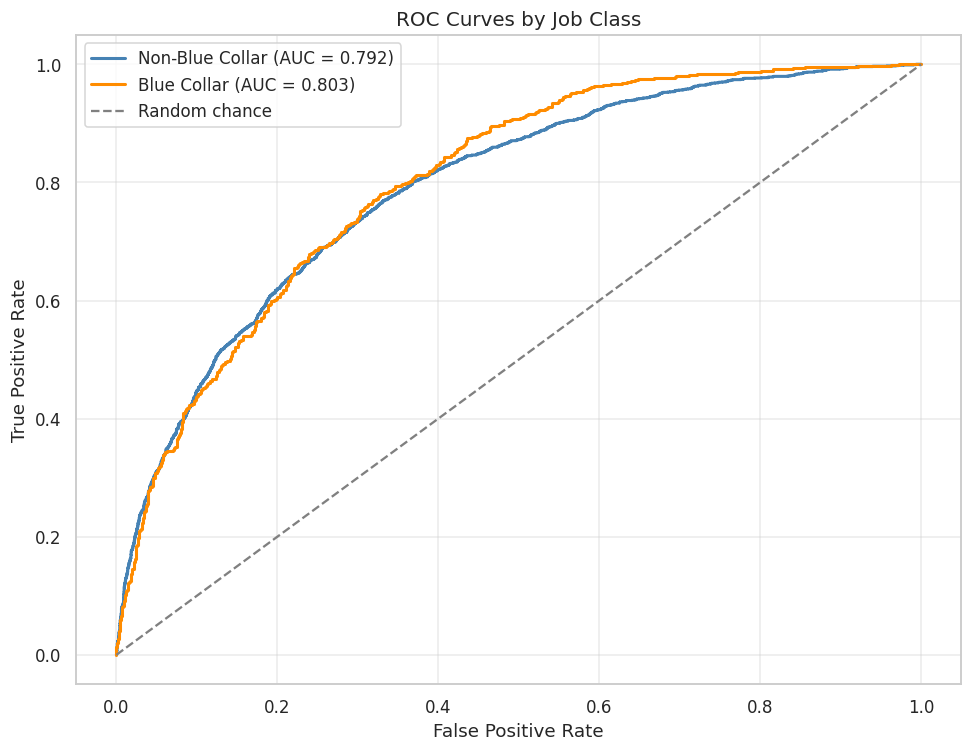

In [13]:
# ROC Curves and AUC
fig, ax = plt.subplots(figsize=(9, 7))

colors = {0: "steelblue", 1: "darkorange"}
labels = {0: "Non-Blue Collar", 1: "Blue Collar"}

for g in [0, 1]:
    sub = df[df["job_bluecollar"] == g]
    fpr, tpr, _ = roc_curve(sub["hadclaim"], sub["probclaim"])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors[g], linewidth=2, label=f"{labels[g]} (AUC = {roc_auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random chance")
ax.set_xlabel("False Positive Rate", fontsize=12)
ax.set_ylabel("True Positive Rate", fontsize=12)
ax.set_title("ROC Curves by Job Class", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


Both groups have similar and acceptable AUC scores:
- Non-Blue Collar: **AUC = 0.792**
- Blue Collar: **AUC = 0.802**

The model's ability to *rank* customers by risk is roughly equal across the two groups. The blue-collar group's marginally higher AUC reflects a wider spread in their predicted probabilities, not a meaningful advantage for them.


## 6. Differential Error Rates

This section examines the *types* of errors the model makes for each group at the 60% threshold. We look at four key error metrics:

| Metric | Definition | Formula |
|--------|-----------|---------|
| **False Positive Rate (FPR)** | Of those who won't claim, what share gets cancelled? | FP / (FP + TN) |
| **False Negative Rate (FNR)** | Of those who will claim, what share is missed? | FN / (TP + FN) |
| **False Discovery Rate (FDR)** | Of those cancelled, what share won't actually claim? | FP / (FP + TP) |
| **False Omission Rate (FOR)** | Of those kept, what share will actually claim? | FN / (FN + TN) |

### 6a. Error rates at the 60% threshold


In [14]:
# Build confusion matrix components
df["TP"] = ((df["hadclaim"] == 1) & (df["highrisk"] == 1)).astype(int)
df["FP"] = ((df["hadclaim"] == 0) & (df["highrisk"] == 1)).astype(int)
df["TN"] = ((df["hadclaim"] == 0) & (df["highrisk"] == 0)).astype(int)
df["FN"] = ((df["hadclaim"] == 1) & (df["highrisk"] == 0)).astype(int)

cm = df.groupby("job_bluecollar")[["TP", "FP", "TN", "FN"]].sum()
cm.index = ["Non-Blue Collar", "Blue Collar"]
cm.index.name = "Job Class"

cm["FPR"] = (cm["FP"] / (cm["FP"] + cm["TN"])).round(4)
cm["FNR"] = (cm["FN"] / (cm["TP"] + cm["FN"])).round(4)
cm["FDR"] = (cm["FP"] / (cm["FP"] + cm["TP"])).round(4)
cm["FOR"] = (cm["FN"] / (cm["FN"] + cm["TN"])).round(4)

print("Error Rates at 60% Threshold")
print(cm[["FPR", "FNR", "FDR", "FOR"]].to_string())


Error Rates at 60% Threshold
                    FPR     FNR     FDR     FOR
Job Class                                      
Non-Blue Collar  0.0264  0.7839  0.2773  0.2038
Blue Collar      0.0613  0.6570  0.2493  0.2736



- **False Positive Rate:** Blue-collar customers who will NOT file a claim are cancelled at a rate of **6.1%**, more than double the non-blue-collar rate of **2.6%**. This means blue-collar customers are significantly more likely to be wrongly cancelled.
- **False Negative Rate:** Non-blue-collar customers who WILL file a claim are missed at a rate of **78.4%**, compared to **65.7%** for blue-collar customers. The model catches a larger share of true claimants in the blue-collar group.
- **False Discovery Rate:** Of all cancelled blue-collar customers, **24.9%** won't actually file a claim. For non-blue-collar, it's **27.7%**. Once flagged as high-risk, a cancelled blue-collar customer is *slightly more likely* to have been a genuine claimant.
- **False Omission Rate:** Of the blue-collar customers *kept* (not cancelled), **27.4%** will actually file a claim, which is higher than the **20.4%** for non-blue-collar customers kept.

The FPR disparity (6.1% vs. 2.6%) is the most alarming finding from an individual-fairness standpoint: blue-collar customers without claims are being cancelled at more than twice the rate of similarly situated non-blue-collar customers.

### 6b. Error rates across all thresholds


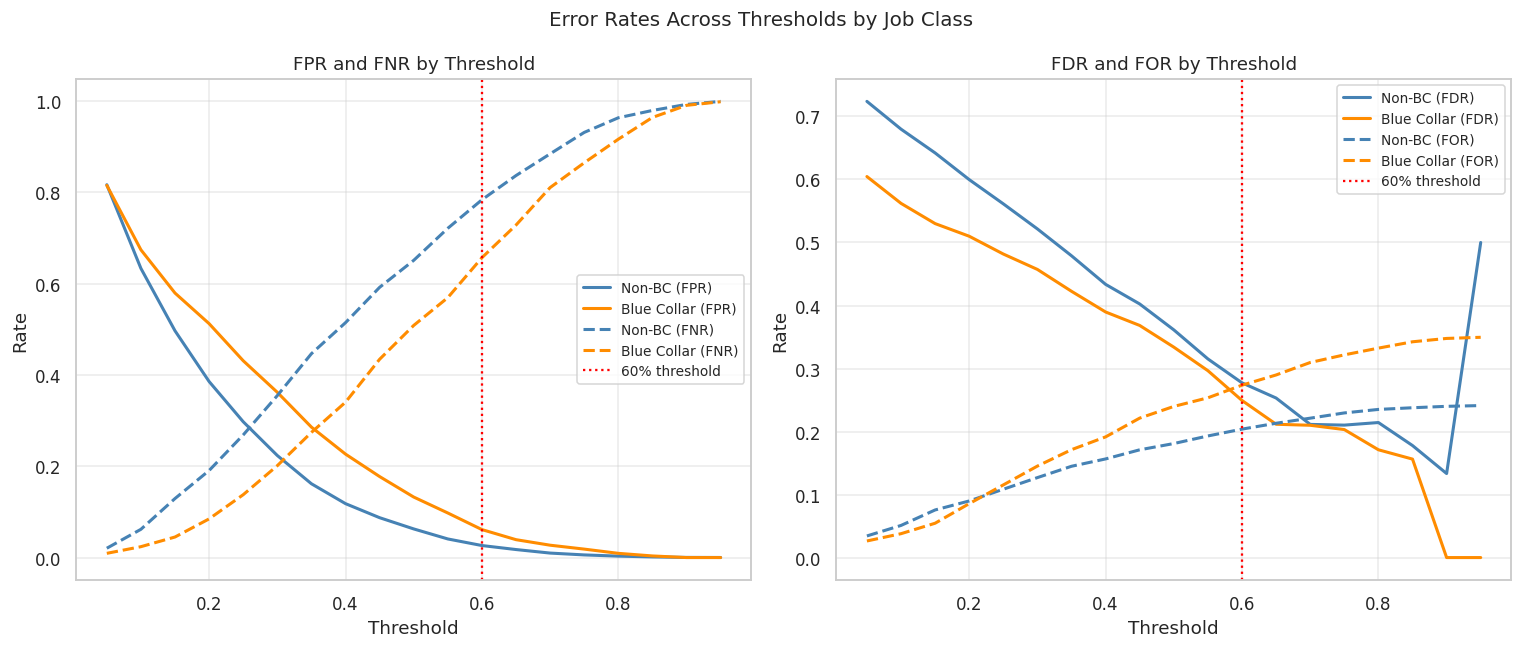

In [15]:
# Error rates across all thresholds
thresholds = [x / 100 for x in range(5, 100, 5)]
fpr_d, fnr_d, fdr_d, for_d = {0: [], 1: []}, {0: [], 1: []}, {0: [], 1: []}, {0: [], 1: []}

for g in [0, 1]:
    sub = df[df["job_bluecollar"] == g]
    for t in thresholds:
        pred = (sub["probclaim"] >= t).astype(int)
        TP = ((pred == 1) & (sub["hadclaim"] == 1)).sum()
        FP = ((pred == 1) & (sub["hadclaim"] == 0)).sum()
        TN = ((pred == 0) & (sub["hadclaim"] == 0)).sum()
        FN = ((pred == 0) & (sub["hadclaim"] == 1)).sum()
        fpr_d[g].append(FP / (FP + TN) if (FP + TN) > 0 else 0)
        fnr_d[g].append(FN / (TP + FN) if (TP + FN) > 0 else 0)
        fdr_d[g].append(FP / (FP + TP) if (FP + TP) > 0 else 0)
        for_d[g].append(FN / (FN + TN) if (FN + TN) > 0 else 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# FPR and FNR
ax = axes[0]
ax.plot(thresholds, fpr_d[0], color="steelblue", linewidth=2, label="Non-BC (FPR)")
ax.plot(thresholds, fpr_d[1], color="darkorange", linewidth=2, label="Blue Collar (FPR)")
ax.plot(thresholds, fnr_d[0], color="steelblue", linestyle="--", linewidth=2, label="Non-BC (FNR)")
ax.plot(thresholds, fnr_d[1], color="darkorange", linestyle="--", linewidth=2, label="Blue Collar (FNR)")
ax.axvline(0.60, color="red", linestyle=":", linewidth=1.5, label="60% threshold")
ax.set_title("FPR and FNR by Threshold", fontsize=12)
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

# FDR and FOR
ax = axes[1]
ax.plot(thresholds, fdr_d[0], color="steelblue", linewidth=2, label="Non-BC (FDR)")
ax.plot(thresholds, fdr_d[1], color="darkorange", linewidth=2, label="Blue Collar (FDR)")
ax.plot(thresholds, for_d[0], color="steelblue", linestyle="--", linewidth=2, label="Non-BC (FOR)")
ax.plot(thresholds, for_d[1], color="darkorange", linestyle="--", linewidth=2, label="Blue Collar (FOR)")
ax.axvline(0.60, color="red", linestyle=":", linewidth=1.5, label="60% threshold")
ax.set_title("FDR and FOR by Threshold", fontsize=12)
ax.set_xlabel("Threshold")
ax.set_ylabel("Rate")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.4)

plt.suptitle("Error Rates Across Thresholds by Job Class", fontsize=13)
plt.tight_layout()
plt.show()


The FPR disparity holds across virtually every threshold. Blue-collar customers who won't actually claim are more likely to be wrongly cancelled regardless of what threshold is chosen. Conversely, the FNR is persistently higher for non-blue-collar customers, meaning the model misses more true claimants in that group.

This pattern is mathematically consistent with the fact that blue-collar customers have higher base rates of claims. When two groups have different base rates, a well-calibrated model will necessarily produce different FPR and FNR values. This tension cannot be resolved by adjusting the threshold alone.

The FDR and FOR picture is more nuanced. At most thresholds the FDR is similar or slightly higher for non-blue-collar customers (cancelled customers who turn out not to claim), while the FOR is higher for blue-collar customers who are kept (customers kept who turn out to claim).


---

## Executive Summary

**To: Management**  
**Re: Fairness Analysis of Auto Insurance Claim Prediction Model — Blue-Collar Customers**

---

### What we did
We analyzed whether the company's logistic regression claim-prediction model treats blue-collar customers (trades workers such as electricians, plumbers, and construction workers) fairly relative to other customers. At the planned 60% probability threshold, the model flags customers for policy cancellation at renewal.

---

### The bottom line: The model shows meaningful unfairness toward blue-collar customers

The analysis reveals several dimensions of concern, summarized below.

---

### Key Finding 1 — Blue-collar customers are cancelled at more than twice the rate

At the 60% threshold, **16.0% of blue-collar customers** will have their policies cancelled, versus only **7.2% of non-blue-collar customers**. Blue-collar workers represent 22% of the customer base but account for **39% of all cancellations**. While blue-collar customers do have a higher actual claim rate (35% vs. 24%), the cancellation rate gap is disproportionate relative to that risk differential.

---

### Key Finding 2 — The model is miscalibrated for blue-collar customers

A regression test shows that, controlling for predicted probability, blue-collar customers have actual claim rates about **2 percentage points higher** than the model predicts. In other words, the model **underestimates the true risk** of blue-collar customers at intermediate probability levels. This likely reflects the fact that the model doesn't use job classification as a feature but also doesn't fully capture the risk factors correlated with blue-collar work through its other variables. Ironically, this means some blue-collar customers are not flagged when they should be, and others near the threshold are flagged inconsistently.

---

### Key Finding 3 — Blue-collar customers who won't claim are cancelled at twice the rate (False Positive Rate)

The most troubling fairness finding from an individual-rights perspective:

| Group | % of Non-Claimants Wrongly Cancelled (FPR) |
|-------|---------------------------------------------|
| Non-Blue Collar | 2.6% |
| **Blue Collar** | **6.1%** |

A blue-collar customer who was never going to file a claim is **2.4 times more likely** to have their policy wrongly cancelled than a non-blue-collar customer in the same situation. This disparity holds at essentially every possible threshold, thus it cannot be fixed by simply adjusting the 60% cutoff.

---

### Key Finding 4 — Model accuracy is lower for blue-collar customers

The model is **73% accurate** for blue-collar customers vs. **79% accurate** for non-blue-collar customers. This performance gap exists across all thresholds, meaning the model is simply less reliable as a predictive tool for blue-collar workers.

---

### What this means

When two groups have different underlying claim rates (as ours do: 35% vs. 24%), a statistically well-calibrated model *must* produce different false positive and false negative rates. Choosing a threshold that reduces the FPR gap for blue-collar customers would raise their FNR and vice versa. There is no easy way around this.

That said, the model has an *additional* problem beyond this mathematical inevitability. It is poorly calibrated for blue-collar customers in the mid-range of risk. This is a fixable model-quality issue, not just a structural fairness tension.

---

### Recommendations

1. **Flag this as a fairness concern before implementing the cancellation policy.** The 2.4x higher false positive rate for blue-collar customers means a disproportionate number of those workers will be wrongly harmed. This has potential legal, reputational, and ethical implications.

2. **Invest in improving model calibration for blue-collar customers.** Consider including more features that are relevant to blue-collar driving patterns (e.g., commercial use, commute patterns) and test whether re-training on a more representative feature set improves calibration for this group.

3. **Consider group-specific thresholds or post-hoc adjustments.** One mitigation strategy is to use different probability thresholds by job class so that the false positive rate is equalized across groups (sometimes called "equalized odds" fairness). This has its own tradeoffs and should be evaluated with legal counsel.

4. **Do not treat model predictions as ground truth.** Given the calibration gap, high-risk blue-collar customers near the 60% boundary should be reviewed with additional scrutiny before cancellation, as the model is less reliable in this range for that group.
